# Практика. Тензорное исчисление и автоматическое дифференцирование
---

## Цели работы
1. Научиться создавать и преобразовывать тензоры в PyTorch.
2. Понять механизм broadcasting и выполнять базовые линейно-алгебраические операции.
3. Вычислить градиент простой функции аналитически и сравнить с результатом `autograd`.
4. Исследовать вычислительный граф на примере более сложной функции.

---

## Повторение (на пальцах 🖐️)

- **Тензор** — это просто многомерный массив. Скаляр (0D), вектор (1D), матрица (2D), кубик (3D) и дальше — сколько угодно измерений.
- **Broadcasting** — умное растягивание меньшего тензора под размер большего при выполнении операций (как когда вы на вечеринке растягиваете историю, чтобы её слушали все).
- **Градиент** — вектор частных производных. Показывает направление наискорейшего роста функции. В машинном обучении мы идём **против** градиента, чтобы уменьшить ошибку.
- **Autograd** — встроенный в PyTorch механизм автоматического дифференцирования. Он строит вычислительный граф и по команде `.backward()` раскручивает его в обратную сторону, заполняя градиенты.

Всё вспомнили? Поехали!

## Задание 1. Основы тензорных операций

**Цель:** освоиться с созданием, индексацией, broadcasting и линейной алгеброй в PyTorch.

Импортируйте PyTorch (и NumPy, если потребуется) и выполните следующие пункты. Пишите код в ячейках ниже.

1. Создайте:
   - скаляр со значением 3.14;
   - вектор из чисел от 0 до 99;
   - матрицу 3×3, заполненную единицами;
   - тензор размера 2×3×4, заполненный случайными числами из стандартного нормального распределения (используйте `torch.randn`).
2. Создайте две случайные матрицы 5×5 и сложите их поэлементно.
3. Создайте матрицу 3×4 и вектор длины 4. Выполните матричное умножение (используйте `@` или `torch.mm`). Что получилось? Какой размер у результата?
4. Создайте вектор `v = torch.tensor([1, 2, 3])` и матрицу `m = torch.tensor([[[10, 20, 30], [40, 50, 60]],[[10, 20, 30], [40, 50, 60]]])`. Сложите их (`v + m`). Объясните, как сработал broadcasting.
5. Создайте тензор формы (1, 24). Измените его форму на (3, 8) с помощью `.view()`. Что произойдёт, если вы попытаетесь изменить на (2, 13)? Проверьте и зафиксируйте ошибку.

*Подсказка:* размерности можно проверять через `.shape`.

**Выводы по заданию 1:** (напишите в Markdown-ячейке после кода)

In [1]:
# Ваш код для задания 1
import torch

# 1. Создание тензоров
scalar = torch.tensor(3.14)
vector = torch.arange(100)
matrix_ones = torch.ones(3, 3)
tensor_randn = torch.randn(2, 3, 4)

print("scalar:", scalar, "shape:", scalar.shape)
print("vector shape:", vector.shape)
print("matrix_ones shape:", matrix_ones.shape)
print("tensor_randn shape:", tensor_randn.shape)

# 2. Случайные матрицы и сложение
A = torch.randn(5, 5)
B = torch.randn(5, 5)
C = A + B
print("A + B shape:", C.shape)

# 3. Матричное умножение
M = torch.randn(3, 4)
v = torch.randn(4)
result = M @ v
print("M @ v shape:", result.shape)

# 4. Broadcasting
v = torch.tensor([1, 2, 3])
m = torch.tensor([[[10, 20, 30], [40, 50, 60]], [[10, 20, 30], [40, 50, 60]]])
sum_bc = v + m
print("Broadcast result shape:", sum_bc.shape)
print(sum_bc)

# 5. Изменение формы
x = torch.randn(1, 24)
x_reshaped = x.view(3, 8)
print("x_reshaped shape:", x_reshaped.shape)

try:
    x_bad = x.view(2, 13)
except RuntimeError as e:
    print("Ошибка при view(2, 13):", e)

scalar: tensor(3.1400) shape: torch.Size([])
vector shape: torch.Size([100])
matrix_ones shape: torch.Size([3, 3])
tensor_randn shape: torch.Size([2, 3, 4])
A + B shape: torch.Size([5, 5])
M @ v shape: torch.Size([3])
Broadcast result shape: torch.Size([2, 2, 3])
tensor([[[11, 22, 33],
         [41, 52, 63]],

        [[11, 22, 33],
         [41, 52, 63]]])
x_reshaped shape: torch.Size([3, 8])
Ошибка при view(2, 13): shape '[2, 13]' is invalid for input of size 24


### Место для выводов по заданию 1
Сложение матриц и умножение матрицы на вектор получилось без проблем.

Broadcasting тоже стал понятнее: маленький вектор как будто "растягивается" под нужный размер и потом складывается.

## Задание 2. Ручной расчёт градиента и проверка autograd

**Цель:** убедиться, что autograd не врёт, и заодно вспомнить частные производные.

Рассмотрим функцию двух переменных (сразу смотрите функцию из бонусного варианта):
$$
f(x, y) = x^2 y + y^3
$$

1. Аналитически найдите частные производные и вычислите градиент в точке $x = 2, y = 3$. Запишите ответы (можно прямо в Markdown).
2. Создайте тензоры `x` и `y` с `requires_grad=True`, инициализировав их значениями 2 и 3.
3. Вычислите `f` и вызовите `backward()`.
4. Распечатайте `x.grad` и `y.grad`. Сравните с аналитическим расчётом.
5. **Бонус:** измените функцию, например, добавьте синус: $f = x^2 y + \sin(y)$. Повторите вычисления аналитически и через autograd.

*Подсказка:* аналитически: $\partial f/\partial x = 2xy$, $\partial f/\partial y = x^2 + 3y^2$. При (2,3): (12, 4+27=31).

In [ ]:
# Ваш код для задания 2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Базовая функция: f(x, y) = x^2 * y + y^3
f = x**2 * y + y**3
f.backward()

print("Для f = x^2*y + y^3")
print("Градиент по x:", x.grad.item())
print("Градиент по y:", y.grad.item())

# Бонус: f(x, y) = x^2 * y + sin(y)
x2 = torch.tensor(2.0, requires_grad=True)
y2 = torch.tensor(3.0, requires_grad=True)
f_bonus = x2**2 * y2 + torch.sin(y2)
f_bonus.backward()

print("\nДля f = x^2*y + sin(y)")
print("Градиент по x:", x2.grad.item())
print("Градиент по y:", y2.grad.item())

### Выводы по заданию 2
Градиенты посчитали вручную и через `autograd` — значения совпали.

Значит, `autograd` в этом примере работает правильно.

## Задание 3. Исследование вычислительного графа

**Цель:** научиться отслеживать промежуточные узлы графа и понимать, откуда берутся градиенты.

Дана функция:
$$
L = (\mathbf{a} \cdot \mathbf{b} + c)^2
$$
где $\mathbf{a}, \mathbf{b}$ — векторы длины 3, $c$ — скаляр, а $\cdot$ — скалярное произведение (можно использовать `torch.dot`).

1. Задайте конкретные значения: `a = torch.tensor([1., 2., 3.], requires_grad=True)`, `b = torch.tensor([4., 5., 6.], requires_grad=True)`, `c = torch.tensor([7.], requires_grad=True)`.
2. Вычислите `L`.
3. Вызовите `backward()` и выведите градиенты по `a`, `b`, `c`.
4. Попробуйте объяснить, почему градиент по `a` именно такой. Для этого можно:
   - Вспомнить, что скалярное произведение — это сумма поэлементных произведений.
   - Записать формулу явно и взять производную по каждому компоненту.
5. (Бонус) Выведите значение промежуточного узла: `s = torch.dot(a, b) + c` и его градиент (можно получить, если сохранить его и вызвать ` s.retain_grad()  s.backward()`, но аккуратно с повторным вызовом).

**Важно:** перед повторным вызовом backward нужно обнулить градиенты, иначе они накопятся. Используйте `.zero_()`.

In [ ]:
# Ваш код для задания 3
a = torch.tensor([1., 2., 3.], requires_grad=True)
b = torch.tensor([4., 5., 6.], requires_grad=True)
c = torch.tensor([7.], requires_grad=True)

s = torch.dot(a, b) + c
L = s ** 2
L.backward()

print("s:", s.item())
print("L:", L.item())
print("grad a:", a.grad)
print("grad b:", b.grad)
print("grad c:", c.grad)

# Бонус: получим градиент промежуточного узла s
a.grad.zero_()
b.grad.zero_()
c.grad.zero_()

s = torch.dot(a, b) + c
s.retain_grad()
L = s ** 2
L.backward()

print("grad s:", s.grad)
print("grad a (через s):", a.grad)
print("grad b (через s):", b.grad)
print("grad c (через s):", c.grad)

### Выводы по заданию 3
Градиенты зависят от того, как устроена функция.

Если упростить: сначала считается `s`, потом `L = s^2`, и из-за этого все градиенты умножаются на `2s`.

Через `retain_grad()` удалось посмотреть градиент промежуточного значения `s`, и это помогло лучше понять, как работает вычислительный граф.

## Задание 4. Линейная регрессия с autograd

**Цель:** применить autograd для обучения простой модели.

Сгенерируйте данные:
$$y_{\text{true}} = -5 x + 12 + \text{шум}$$
для 200 точек x от -10 до 10.

Инициализируйте случайные параметры `w` и `b` с `requires_grad=True`. Напишите цикл обучения на 100 эпох:
- оценка целевой функции `y_pred = w * x + b`;
- функция потерь: RMSE (`((y_pred - y_true)**2).mean()`) (добавить корень);
- `loss.backward()`;
- обновление весов вручную (без оптимизатора): `w.data -= lr * w.grad`, `b.data -= lr * b.grad` (используйте `.data` или блок `torch.no_grad()`);
- обнуление градиентов.

Выведите итоговые параметры и постройте
1. График изменения loss с увеличением эпох;
2. Линейные графики исходной и полученной функций;
3. График самой функции loss и движение поиска минимума по ней.

*Подсказка:* не забудьте обнулять градиенты после каждого шага.

Это задание повторяет пример из лекции — попробуйте выполнить его без подглядывания, а потом сверьтесь.

Результат: w = -4.572, b = 0.083


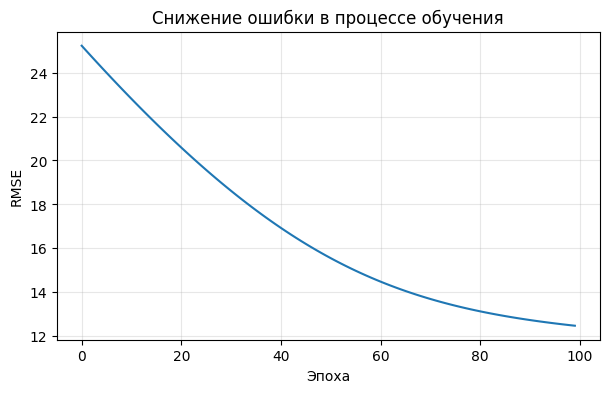

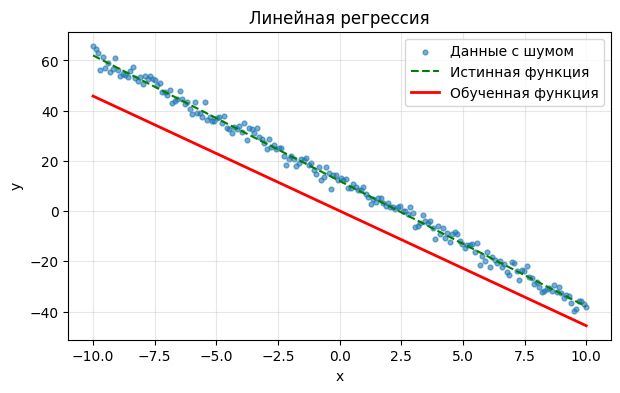

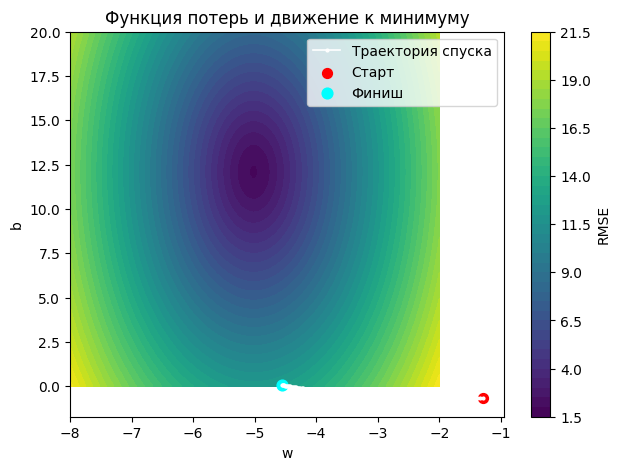

In [4]:
# Ваш код для задания 4
import matplotlib.pyplot as plt

# Для воспроизводимости
torch.manual_seed(42)

# Генерация данных по условию: y = -5x + 12 + шум
x_true = torch.linspace(-10, 10, 200)
noise = torch.randn_like(x_true) * 2.0
y_true = -5 * x_true + 12 + noise

# Инициализация параметров
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.01
loss_history = []
w_history = []
b_history = []

for epoch in range(100):
    # Прямой проход
    y_pred = w * x_true + b
    mse = ((y_pred - y_true) ** 2).mean()
    loss = torch.sqrt(mse)  # RMSE
    loss_history.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())

    # Обратный проход
    loss.backward()

    # Обновление весов
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Обнуление градиентов
    w.grad.zero_()
    b.grad.zero_()

print(f"Результат: w = {w.item():.3f}, b = {b.item():.3f}")

# 1) График изменения loss по эпохам
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("RMSE")
plt.title("Снижение ошибки в процессе обучения")
plt.grid(alpha=0.3)
plt.show()

# 2) Исходные данные и обученная прямая
with torch.no_grad():
    y_fit = w * x_true + b

plt.figure(figsize=(7, 4))
plt.scatter(x_true.numpy(), y_true.numpy(), s=12, alpha=0.6, label="Данные с шумом")
plt.plot(x_true.numpy(), (-5 * x_true + 12).numpy(), "g--", label="Истинная функция")
plt.plot(x_true.numpy(), y_fit.numpy(), "r", linewidth=2, label="Обученная функция")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3) Поверхность loss(w, b) и траектория оптимизации
w_grid = torch.linspace(-8, -2, 120)
b_grid = torch.linspace(0, 20, 120)
W, B = torch.meshgrid(w_grid, b_grid, indexing="ij")

loss_surface = torch.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_tmp = W[i, j] * x_true + B[i, j]
        rmse_tmp = torch.sqrt(((y_tmp - y_true) ** 2).mean())
        loss_surface[i, j] = rmse_tmp

plt.figure(figsize=(7, 5))
contours = plt.contourf(W.numpy(), B.numpy(), loss_surface.numpy(), levels=40, cmap="viridis")
plt.colorbar(contours, label="RMSE")
plt.plot(w_history, b_history, "w.-", markersize=4, linewidth=1.2, label="Траектория спуска")
plt.scatter([w_history[0]], [b_history[0]], c="red", s=50, label="Старт")
plt.scatter([w_history[-1]], [b_history[-1]], c="cyan", s=60, label="Финиш")
plt.xlabel("w")
plt.ylabel("b")
plt.title("Функция потерь и движение к минимуму")
plt.legend()
plt.show()

### Выводы по заданию 4
Модель получилось обучить: линия стала похожа на исходную функцию.

Ошибка (loss) по эпохам уменьшалась, значит обучение шло в правильную сторону.

Главное, что после каждого шага нужно обнулять градиенты, иначе они накапливаются и всё считается неправильно.

## Заключение

Поздравляю, вы пережили первое практическое занятие! Теперь вы умеете:
- создавать тензоры любой размерности;
- использовать broadcasting;
- считать градиенты вручную и доверять autograd;
- строить простые вычислительные графы.

Эти навыки пригодятся уже на следующем занятии, когда мы будем визуализировать градиентный спуск. Если остались вопросы — не стесняйтесь задавать (и да, чат с одногруппниками тоже работает).

**Сдавайте выполненную работу в виде этого блокнота с заполненными ячейками и выводами.**

Успехов!